In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Data Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Data Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Data Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Data Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Data Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Data Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Data Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Data Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [3]:
print("Columns in df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.columns)
print("Columns in df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.columns)

Columns in df_with_selected_features_and_all_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')
Columns in df_with_selected_features_and_no_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')


In [4]:
print("Columns in df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.columns)
print("Columns in df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.columns)

Columns in df_with_all_outliers_and_all_features:  Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

In [5]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42)

# **Desicion Tree Classifier without Hyperparameter Tuning**

In [6]:
dt_a_o_a_f = DecisionTreeClassifier(random_state=42)
dt_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
dt_a_o_s_f = DecisionTreeClassifier(random_state=42)
dt_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
dt_n_o_a_f = DecisionTreeClassifier(random_state=42)
dt_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
dt_n_o_s_f = DecisionTreeClassifier(random_state=42)
dt_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

dt_a_o_a_f_pred = dt_a_o_a_f.predict(X_test_a_o_a_f)
dt_a_o_s_f_pred = dt_a_o_s_f.predict(X_test_a_o_s_f)
dt_n_o_a_f_pred = dt_n_o_a_f.predict(X_test_n_o_a_f)
dt_n_o_s_f_pred = dt_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - Decision Tree Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, dt_a_o_a_f_pred))
print("Classification Report - Decision Tree Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, dt_a_o_s_f_pred))

Classification Report - Decision Tree Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.75      0.65      0.69       316
           1       0.39      0.42      0.40       151
           2       0.76      0.82      0.79       418

    accuracy                           0.69       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.69      0.69      0.69       885

Classification Report - Decision Tree Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       316
           1       0.31      0.29      0.30       151
           2       0.77      0.77      0.77       418

    accuracy                           0.67       885
   macro avg       0.59      0.60      0.59       885
weighted avg       0.67      0.67      0.67       885



In [7]:
print("Classification Report - Decision Tree Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, dt_n_o_a_f_pred))
print("Classification Report - Decision Tree Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, dt_n_o_s_f_pred))

Classification Report - Decision Tree Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70       256
           1       0.41      0.37      0.39       169
           2       0.78      0.78      0.78       442

    accuracy                           0.68       867
   macro avg       0.62      0.63      0.62       867
weighted avg       0.68      0.68      0.68       867

Classification Report - Decision Tree Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       256
           1       0.42      0.33      0.37       169
           2       0.81      0.78      0.79       442

    accuracy                           0.69       867
   macro avg       0.63      0.63      0.63       867
weighted avg       0.69      0.69      0.69       867



Confusion Matrix - Decision Tree Classifier with All Outliers and All Features:


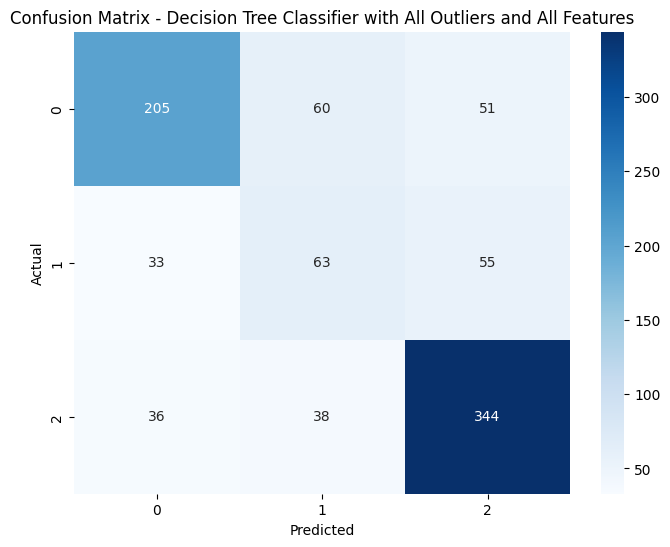

Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features:


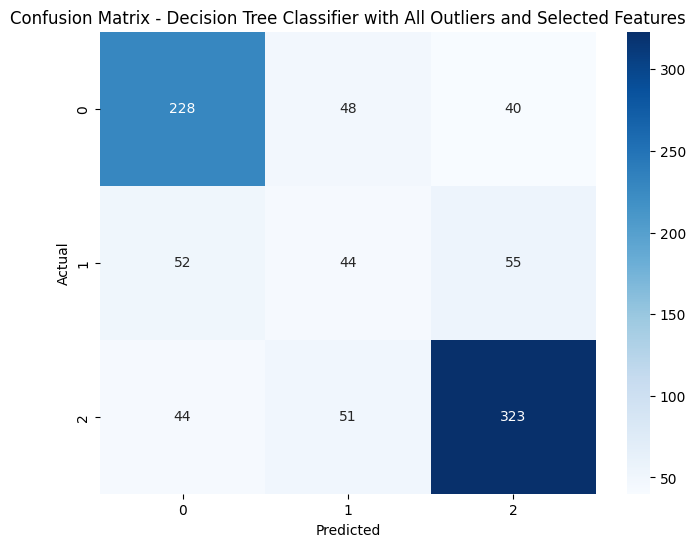

Confusion Matrix - Decision Tree Classifier with No Outliers and All Features:


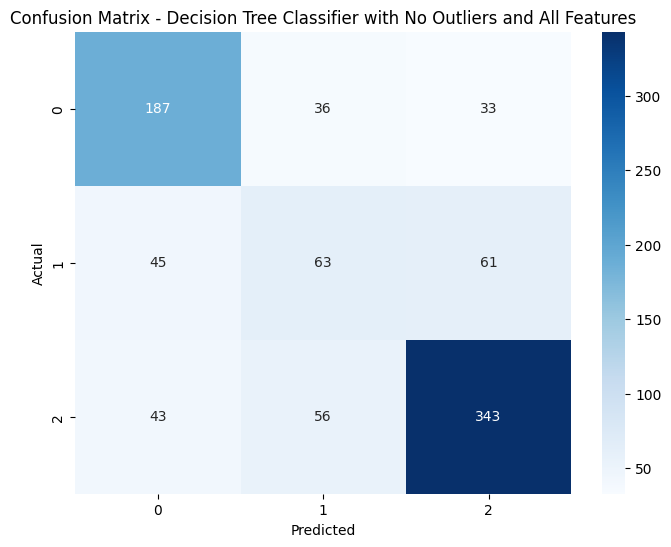

Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features:


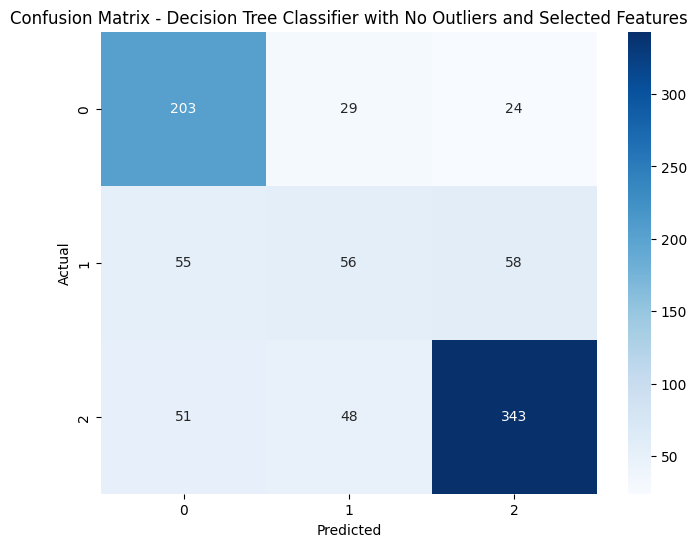

In [8]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - Decision Tree Classifier with All Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, dt_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, dt_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, dt_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, dt_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Accuracy Score
print("Accuracy Score - Decision Tree Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, dt_a_o_a_f_pred))
print("Accuracy Score - Decision Tree Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, dt_a_o_s_f_pred))
print("Accuracy Score - Decision Tree Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, dt_n_o_a_f_pred))
print("Accuracy Score - Decision Tree Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, dt_n_o_s_f_pred))

Accuracy Score - Decision Tree Classifier with All Outliers and All Features: 0.6915254237288135
Accuracy Score - Decision Tree Classifier with All Outliers and Selected Features: 0.672316384180791
Accuracy Score - Decision Tree Classifier with No Outliers and All Features: 0.6839677047289504
Accuracy Score - Decision Tree Classifier with No Outliers and Selected Features: 0.6943483275663207


In [10]:
# ROC AUC Score
print("ROC AUC Score - Decision Tree Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, dt_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, dt_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, dt_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Decision Tree Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, dt_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - Decision Tree Classifier with All Outliers and All Features: 0.7345263558592133
ROC AUC Score - Decision Tree Classifier with All Outliers and Selected Features: 0.7372085790927594
ROC AUC Score - Decision Tree Classifier with No Outliers and All Features: 0.7303766833125888
ROC AUC Score - Decision Tree Classifier with No Outliers and Selected Features: 0.7789550999105987


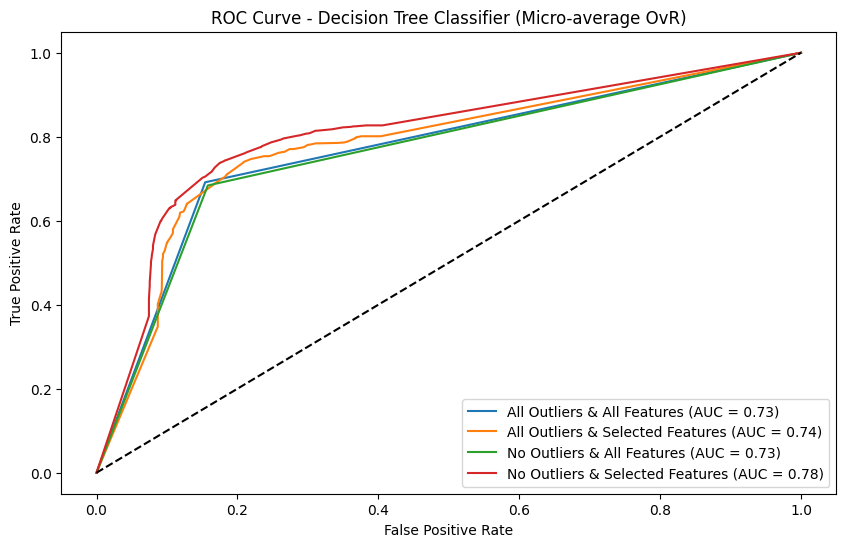

In [11]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, dt_a_o_a_f.predict_proba(X_test_a_o_a_f), dt_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, dt_a_o_s_f.predict_proba(X_test_a_o_s_f), dt_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, dt_n_o_a_f.predict_proba(X_test_n_o_a_f), dt_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, dt_n_o_s_f.predict_proba(X_test_n_o_s_f), dt_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

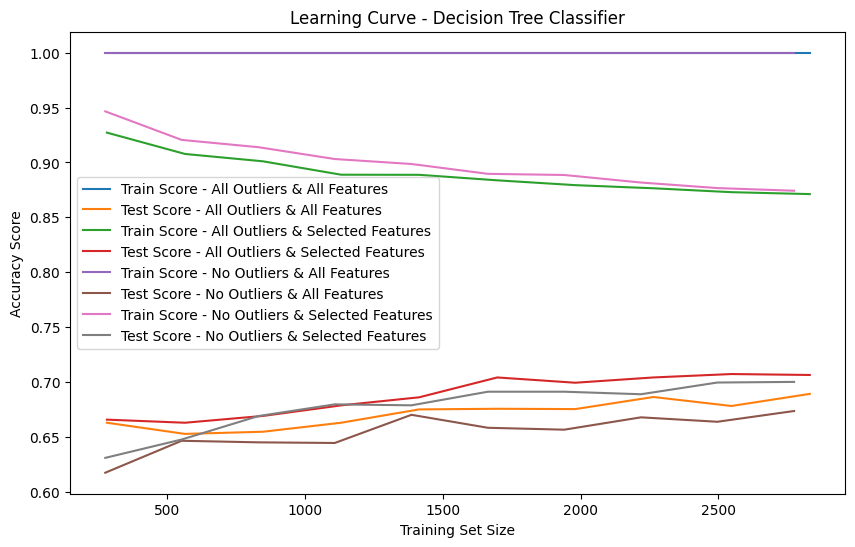

In [12]:
# Learning Curve
train_sizes_a_o_a_f, train_scores_a_o_a_f, test_scores_a_o_a_f = learning_curve(
    dt_a_o_a_f, X_train_a_o_a_f, y_train_a_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_a_o_s_f, train_scores_a_o_s_f, test_scores_a_o_s_f = learning_curve(
    dt_a_o_s_f, X_train_a_o_s_f, y_train_a_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_a_f, train_scores_n_o_a_f, test_scores_n_o_a_f = learning_curve(
    dt_n_o_a_f, X_train_n_o_a_f, y_train_n_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_s_f, train_scores_n_o_s_f, test_scores_n_o_s_f = learning_curve(
    dt_n_o_s_f, X_train_n_o_s_f, y_train_n_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_a_o_a_f, np.mean(train_scores_a_o_a_f, axis=1), label='Train Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_a_f, np.mean(test_scores_a_o_a_f, axis=1), label='Test Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_s_f, np.mean(train_scores_a_o_s_f, axis=1), label='Train Score - All Outliers & Selected Features')
plt.plot(train_sizes_a_o_s_f, np.mean(test_scores_a_o_s_f, axis=1), label='Test Score - All Outliers & Selected Features')
plt.plot(train_sizes_n_o_a_f, np.mean(train_scores_n_o_a_f, axis=1), label='Train Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_a_f, np.mean(test_scores_n_o_a_f, axis=1), label='Test Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_s_f, np.mean(train_scores_n_o_s_f, axis=1), label='Train Score - No Outliers & Selected Features')
plt.plot(train_sizes_n_o_s_f, np.mean(test_scores_n_o_s_f, axis=1), label='Test Score - No Outliers & Selected Features')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - Decision Tree Classifier')
plt.legend(loc='best')
plt.show()

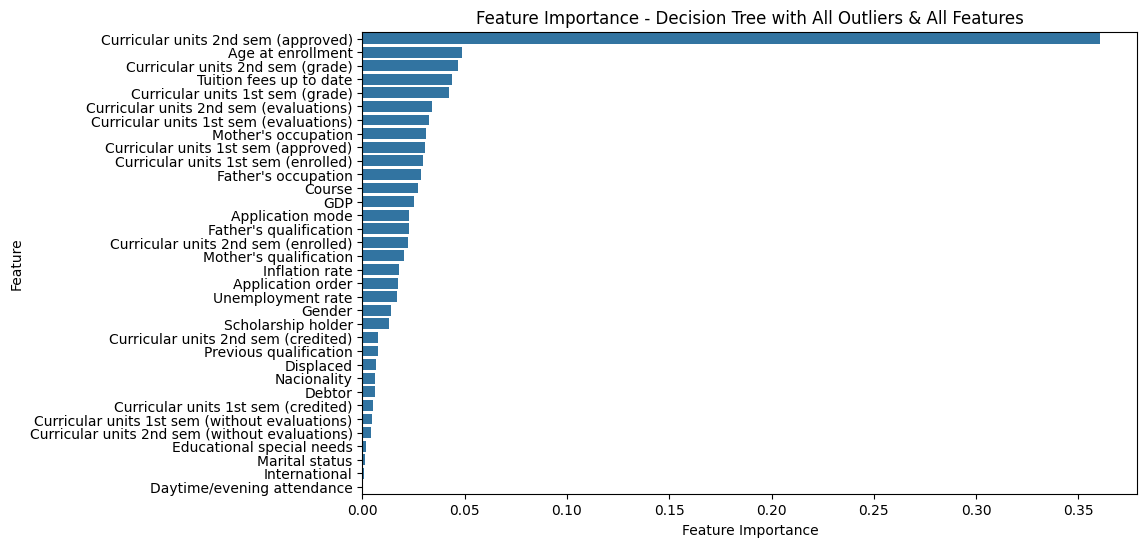

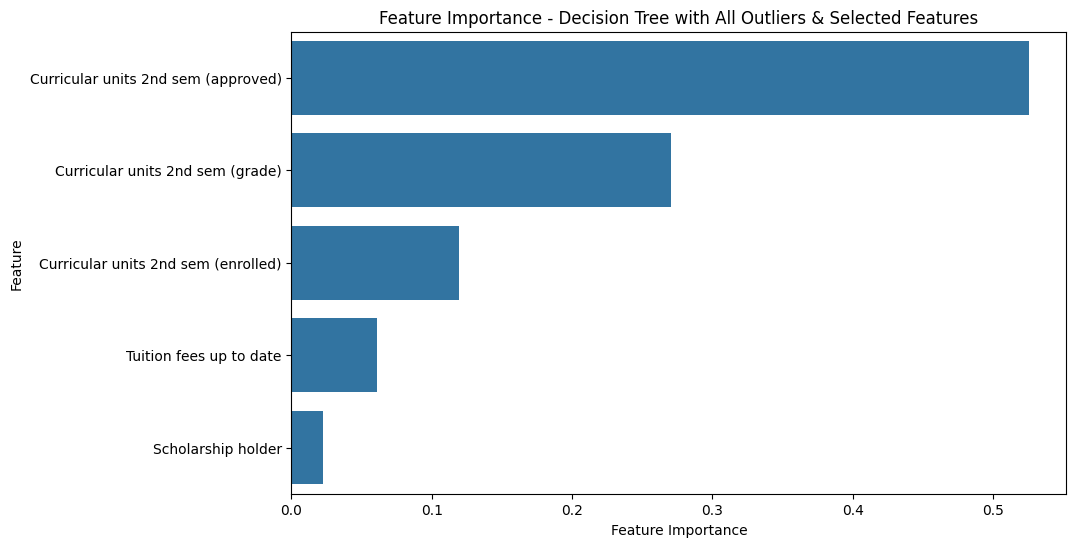

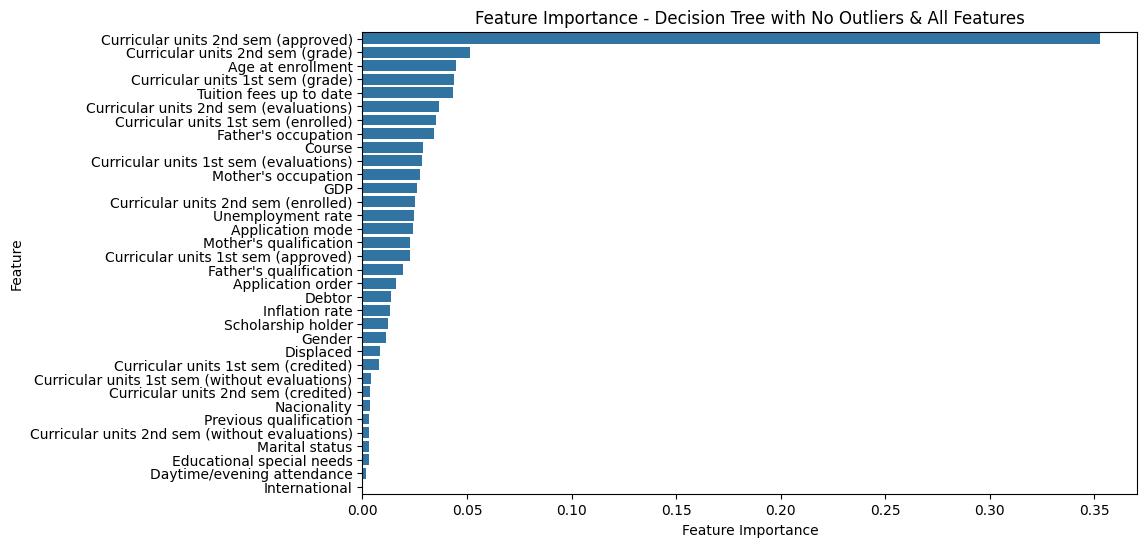

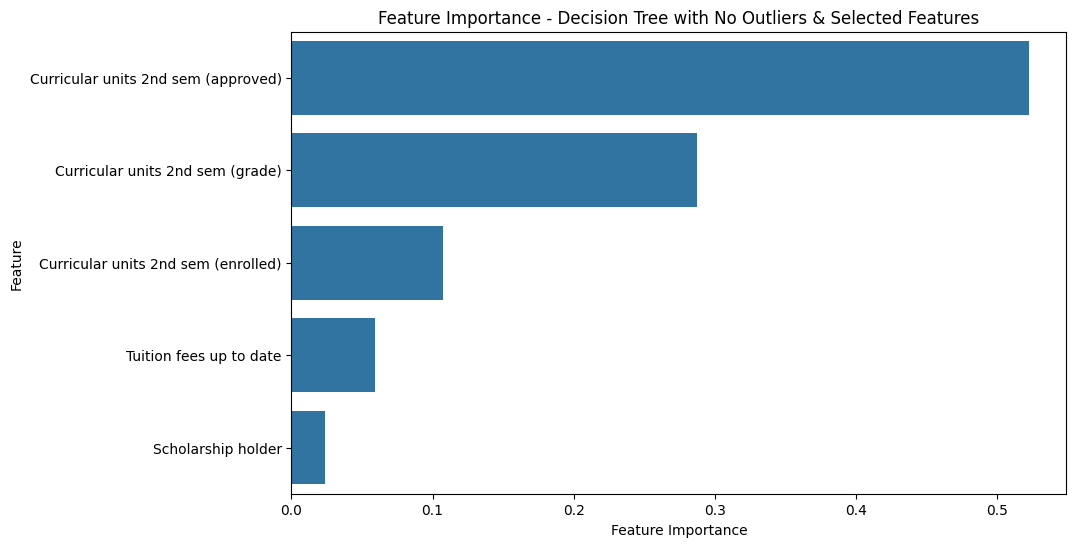

In [13]:
def plot_feature_importance(model, feature_names, title):
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[indices], y=np.array(feature_names)[indices])
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()
plot_feature_importance(dt_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - Decision Tree with All Outliers & All Features")
plot_feature_importance(dt_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - Decision Tree with All Outliers & Selected Features")
plot_feature_importance(dt_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - Decision Tree with No Outliers & All Features")
plot_feature_importance(dt_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - Decision Tree with No Outliers & Selected Features")